Statistics for ML

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set visual theme
sns.set_theme(style= 'whitegrid')

In [5]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


Measure of Central Tendency

In [7]:
print(df.columns)

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')


In [8]:
col = df['total_bill']
print(col)

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64


In [16]:
mean_val = col.mean()
mode_val = col.mode()[0]
median_val = np.median(col)
# :.2f rounds to 2 d.p, $ is dollar sign for currency
print(f'Mean of total bil is ${mean_val:.2f}') 
print(f'Mode of total bill is ${mode_val}')
print(f'Median of total bill is ${median_val:.2f}')

Mean of total bil is $19.79
Mode of total bill is $13.42
Median of total bill is $17.80


Distribution Curve

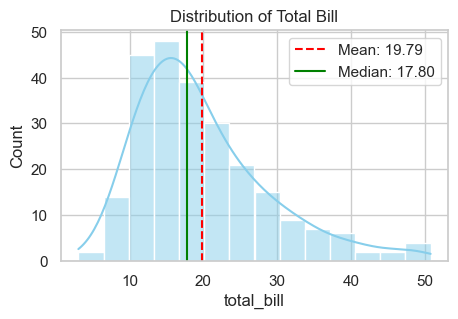

In [20]:
# Visualize the histogram to understand distribution
plt.figure(figsize=(5,3))
sns.histplot(col, kde=True, color='skyblue')
plt.axvline(mean_val, color='red', linestyle= '--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green',linestyle='-', label=f'Median: {median_val:.2f}')
plt.legend()
plt.title('Distribution of Total Bill')
plt.show()

Histogram showed data is positive skewed

For positive skew, mean > median. The opposite is true for negative skew


**Measure of Spread**

In [27]:
# Range
data_range = col.max() - col.min()
variance = col.var(ddof=0)
std = col.std(ddof=0)
#Inter Quartile Range
Q1 = np.percentile(col, 25)
Q3 = np.percentile(col, 75)
IQR = Q3 - Q1

print(f'Range is ${data_range}')
print(f'Variance is {variance:.2f}')
print(f'Standard deviation is {std:.2f}')
print(f'IQR is {IQR:.2f}')

Range is $47.74
Variance is 78.93
Standard deviation is 8.88
IQR is 10.78


Data distribution and skewness

In [30]:
print(f"Skewness of Tips: {df['tip'].skew():.2f}")
print(f'Skewness of Total Bill: {df["total_bill"].skew():.2f}')

Skewness of Tips: 1.47
Skewness of Total Bill: 1.13


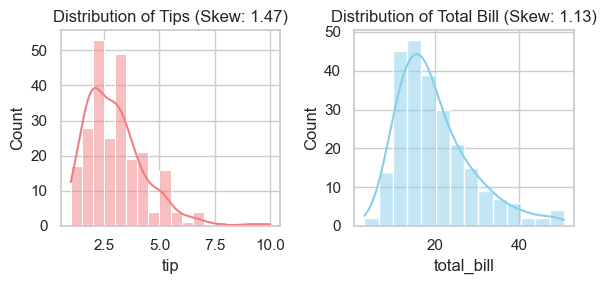

In [34]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
sns.histplot(df['tip'], kde=True, color='lightcoral')
plt.title(f'Distribution of Tips (Skew: {df["tip"].skew():.2f})')

plt.subplot(1,2,2)
sns.histplot(df['total_bill'], kde = True, color='skyblue')
plt.title(f'Distribution of Total Bill (Skew: {df["total_bill"].skew():.2f})')

plt.tight_layout()
plt.show()

Outlier detection

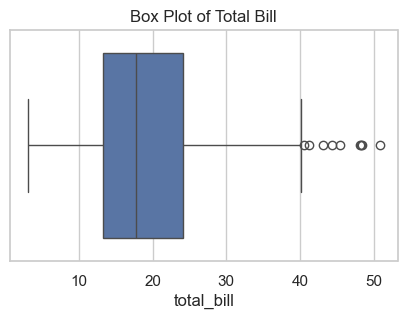

Lower Bound: -2.82
Upper Bound: 40.30
Number of outliers: 9


In [37]:
plt.figure(figsize =(5,3))
sns.boxplot(x=df['total_bill'])
plt.title('Box Plot of Total Bill')
plt.show()

Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound: {lower_bound:.2f}')
print(f'Upper Bound: {upper_bound:.2f}')

outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]
print('Number of outliers:', len(outliers))

In [38]:
 outliers 

,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


Correlation Analysis

In [39]:
# Correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


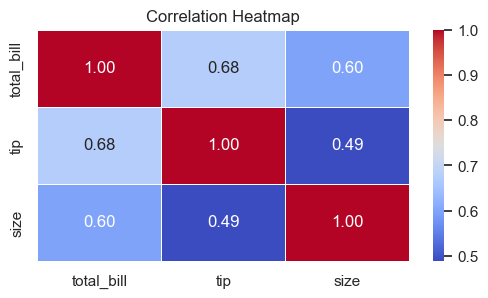


Correlation between Total Bill and Tip:
0.6757341092113648


In [40]:
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()
print('\nCorrelation between Total Bill and Tip:')
print(corr_matrix.loc['total_bill', 'tip'])